### GM(1, 1)预测实例

### 例 15.2：中国蔬菜产量灰色 GM(1,1) 预测模型应用

#### 背景与目标
利用 1995 - 2001 年中国蔬菜产量数据，通过灰色系统理论的 **GM(1,1) 模型** 预测 2002 年产量，并检验模型精度 。


### 1. 数据与模型基础
- **原始数据**（表 15.1）：1995 - 2001 年蔬菜产量序列 $ x^{(0)} = (25723, 30379, 34473, 38485, 40514, 42400, 48337) $ 。  
- **模型选择**(需校验级比)：灰色 GM(1,1) 模型，适用于小样本、贫信息的预测场景，通过 **累加生成** 处理原始数据，弱化随机性 。  


### 2. 建模步骤
#### （1）数据检验  
构造参考序列 $ x^{(0)} $，验证级比符合建模要求，确认可用于 GM(1,1) 建模 。  


#### （2）模型构建（核心步骤）  
- **累加生成序列** $ x^{(1)} $：  
  对原始数据累加，消弱波动，公式：  
  $$
  x^{(1)}(k) = \sum_{i=1}^k x^{(0)}(i)
  $$  
  计算得 $ x^{(1)} = (25723, 56102, 90575, 129060, 169574, 211974, 260311) $ 。  

- **均值生成序列** $ z^{(1)} $：  
  对 $ x^{(1)} $ 做邻值平均，公式：  
  $$
  z^{(1)}(k) = 0.5x^{(1)}(k) + 0.5x^{(1)}(k-1) \quad (k=2,3,\dots,7)
  $$  

- **参数辨识**：  
  构造矩阵 $ \boldsymbol{Y} $（原始数据残差项）和 $ \boldsymbol{B} $（均值序列与常数项），通过最小二乘法求解模型参数 $ \hat{u} = [\hat{a}, \hat{b}]^T $，得：  
  $$
  \hat{u} = \begin{bmatrix} -0.0843 \\ 27858.4508 \end{bmatrix}
  $$  

- **GM(1,1) 模型**：  
  - 灰微分方程：$ x^{(0)}(k) - 0.0843z^{(1)}(k) = 27858.4508 $  
  - 白化方程（微分形式）：$ \frac{dx^{(1)}(t)}{dt} - 0.0843x^{(1)}(t) = 27858.4508 $  
  - 时间响应式（预测核心）：  
    $$
    \hat{x}^{(1)}(k+1) = 356328.9910e^{0.0843k} - 330605.9910
    $$  


#### （3）预测与检验  
- **预测值计算**：  
  通过累减还原（$ \hat{x}^{(0)}(k+1) = \hat{x}^{(1)}(k+1) - \hat{x}^{(1)}(k) $），得到 1995 - 2002 年预测值（表 15.2），2002 年预测产量为 **51939.5524** 。  

- **精度检验**：  
  计算相对误差 $ \delta(k) $，所有误差均小于 10%（表 15.2、图 15.2），模型精度为“优”，可用于预测 。  


### 3. 关键结论  
GM(1,1) 模型有效处理了蔬菜产量的小样本数据，2002 年预测值为 51939.55，模型精度验证可靠，适用于此类贫信息序列的预测场景 。


级比的范围: [0.8467362322657098, 0.9555188679245283]
级比的容许范围: [0.7788007830714049, 1.2840254166877414]

1995~2002年的预测值:
[25723.         31327.3567122  34081.56224489 37077.90911705
 40337.68565577 43884.05179287 47742.20361062 51939.55235392]

--------------------------

1995年的相对误差: 0.000000%
1996年的相对误差: 3.121751%
1997年的相对误差: 1.135491%
1998年的相对误差: 3.656206%
1999年的相对误差: 0.435194%
2000年的相对误差: 3.500122%
2001年的相对误差: 1.230520%


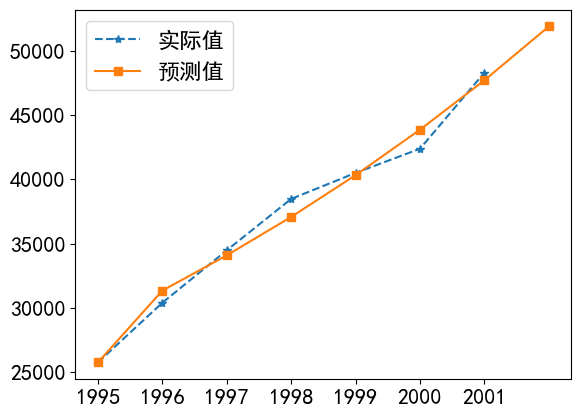

In [35]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 16
plt.rcParams['font.sans-serif'] = ['SimHei']

x0 = np.array([25723, 30379, 34473, 38485, 40514, 42400, 48337])
n = len(x0)
jibi = x0[:-1] / x0[1:]  # 求级比 x_k-1 / x_k
bd1 = [jibi.min(), jibi.max()]  # 求级比的范围
bd2 = [np.exp(-2 / (n+1)), np.exp(2 / (n+1))]  # 求级比的容许范围
print(f"级比的范围: {bd1}")
print(f"级比的容许范围: {bd2}")

x1 = np.cumsum(x0)  # 求累加数列
z = (x1[:-1] + x1[1:]) / 2  # z(k)
B = np.vstack([-z, np.ones(n - 1)]).T
u = np.linalg.pinv(B) @ x0[1:]  # pinv求伪逆(B^+ = (B.TB)^(-1)B.T,x0[1:] = Y, 最小二乘法拟合得到参数

# 求微分方程的解析解--时间响应式
# sp.var('t')
# sp.var('x', cls=sp.Function)
# eq = x(t).diff(t) + u[0] * x(t) - x[1]  # 定义白化方程

t_sym = sp.symbols('t')  # 使用不同的变量名避免冲突
x_func = sp.Function('x')  # 定义函数符号
x = x_func(t_sym)  # 定义函数 x(t)
 
# 正确的微分方程: dx/dt + a*x = b
eq = sp.Eq(sp.diff(x, t_sym) + u[0] * x, u[1])
solution = sp.dsolve(eq, x, ics={x_func(0): x0[0]})  # 求解白化方程
xt = solution.rhs  # 提取符号解右手边的公式
xt = sp.lambdify(t_sym, xt, 'numpy')  # 转化为匿名函数,时间响应式,类型: <function _lambdifygenerated(t)>

# 参数检验+预测预报
t = np.arange(n+1)  # n+1 预测第2002年的产量,(8,)
xt1 = xt(t)  # 求模型的预测值
x0_pred = np.hstack([x0[0], np.diff(xt1)])  # 还原数据
x2002 = x0_pred[-1]  # 提取2002年的预测值
cha = x0 - x0_pred[:-1]
delta = np.abs(cha / x0) * 100
print(f"\n1995~2002年的预测值:\n{x0_pred}")
print('\n--------------------------\n')
for i, error in enumerate(delta, 1):
    print(f"{i+1994}年的相对误差: {error:.6f}%")


t0 = np.arange(1995, 2002)
t1 = np.arange(1995, 2003)
plt.plot(t0, x0, '*--')
plt.plot(t1, x0_pred, 's-')
plt.legend(('实际值', '预测值'))
plt.xticks(np.arange(1995, 2002))
plt.show()